In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import seaborn as sns

Пункт 2 : Загрузка данных в датафрейм.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Пункт 3 : Вывод статистической информации о наборе данных.

In [75]:
df = pd.read_csv('/content/drive/MyDrive/database_gas.csv')
print("Информация о датасете:")
df.info()

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416153 entries, 0 to 416152
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   timestamp      416153 non-null  object 
 1   temperature    416153 non-null  float64
 2   humidity       416153 non-null  float64
 3   CO2CosIRValue  416153 non-null  float64
 4   CO2MG811Value  416153 non-null  float64
 5   MOX1           416153 non-null  float64
 6   MOX2           416153 non-null  float64
 7   MOX3           416153 non-null  float64
 8   MOX4           416153 non-null  float64
 9   COValue        416153 non-null  float64
dtypes: float64(9), object(1)
memory usage: 31.8+ MB


Пункт 4 : Вывод названия строк и столбцов.

In [76]:
print(f"\nКоличество столбцов: {len(df.columns)}")
print("Названия столбцов:")
print(df.columns)
print(f"\nКоличество строк: {len(df)}")
print("Индексы строк:")
print(df.index)


Количество столбцов: 10
Названия столбцов:
Index(['timestamp', 'temperature', 'humidity', 'CO2CosIRValue',
       'CO2MG811Value', 'MOX1', 'MOX2', 'MOX3', 'MOX4', 'COValue'],
      dtype='object')

Количество строк: 416153
Индексы строк:
RangeIndex(start=0, stop=416153, step=1)


Пункт 5 : Замена категориальных данных колличественными

In [77]:
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
print(f"\n ДО ЗАМЕНЫ:")
print(f"Найдено категориальных столбцов: {len(categorical_columns)}")
print(f"Имена столбцов: {categorical_columns}")

if len(categorical_columns) > 0:
    print("\nПервые 5 строк ДО замены:")
    print(df[categorical_columns].head())

if len(categorical_columns) > 0:
    print(" Замена категориальных данных")

    for col in categorical_columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        print(f"\n  ✓ Столбец '{col}' закодирован:")

print("ПОСЛЕ ЗАМЕНЫ")

if len(categorical_columns) > 0:
    print(f"\nПервые 5 строк ПОСЛЕ замены:")
    print(df[categorical_columns].head())


 ДО ЗАМЕНЫ:
Найдено категориальных столбцов: 1
Имена столбцов: ['timestamp']

Первые 5 строк ДО замены:
                          timestamp
0  2019-11-06 11:37:13.038174+01:00
1  2019-11-06 11:37:32.744996+01:00
2  2019-11-06 11:37:53.018087+01:00
3  2019-11-06 11:38:13.093151+01:00
4  2019-11-06 11:38:33.032832+01:00
 Замена категориальных данных

  ✓ Столбец 'timestamp' закодирован:
ПОСЛЕ ЗАМЕНЫ

Первые 5 строк ПОСЛЕ замены:
   timestamp
0          0
1          1
2          2
3          3
4          4


Пункт 6 : График Matplotlib

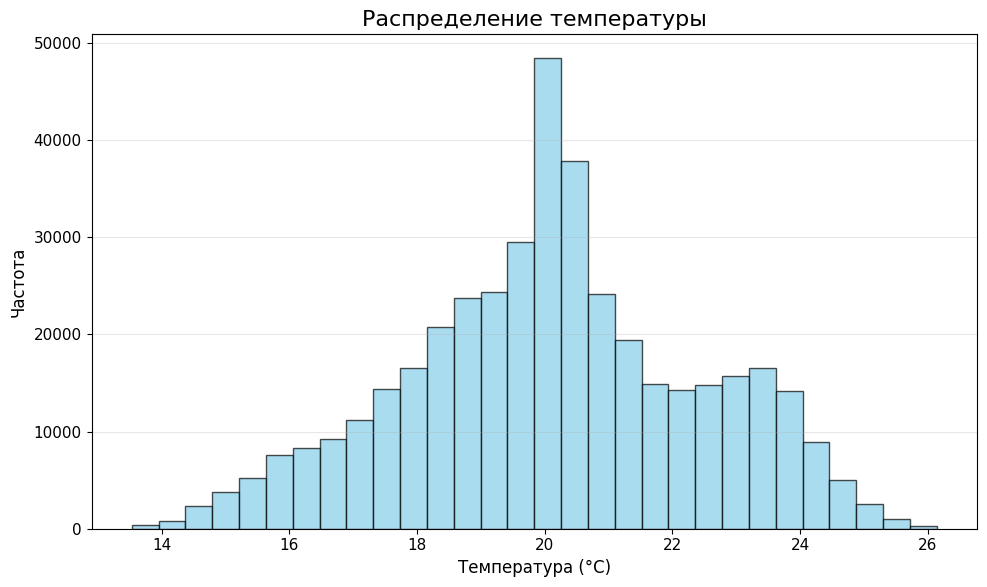

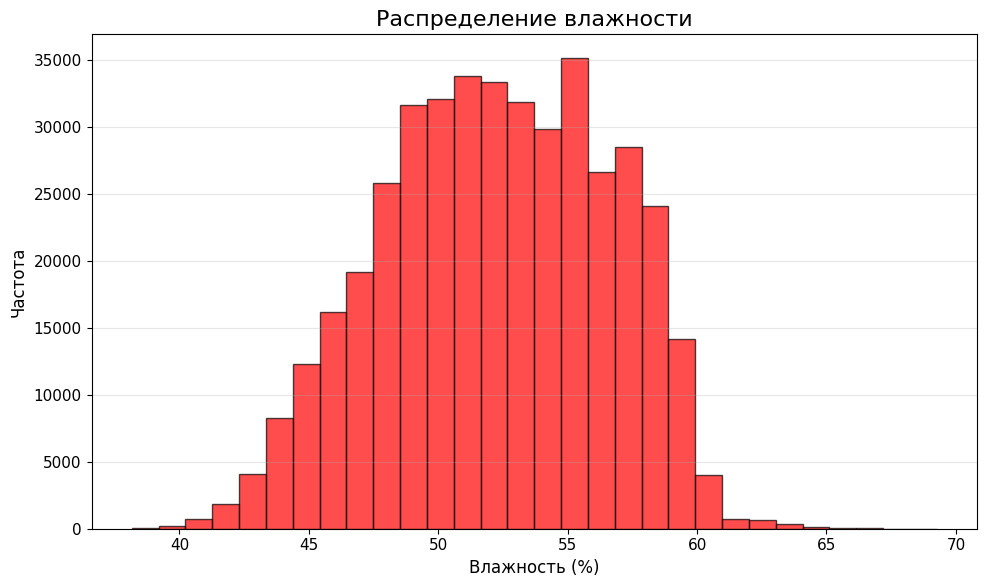

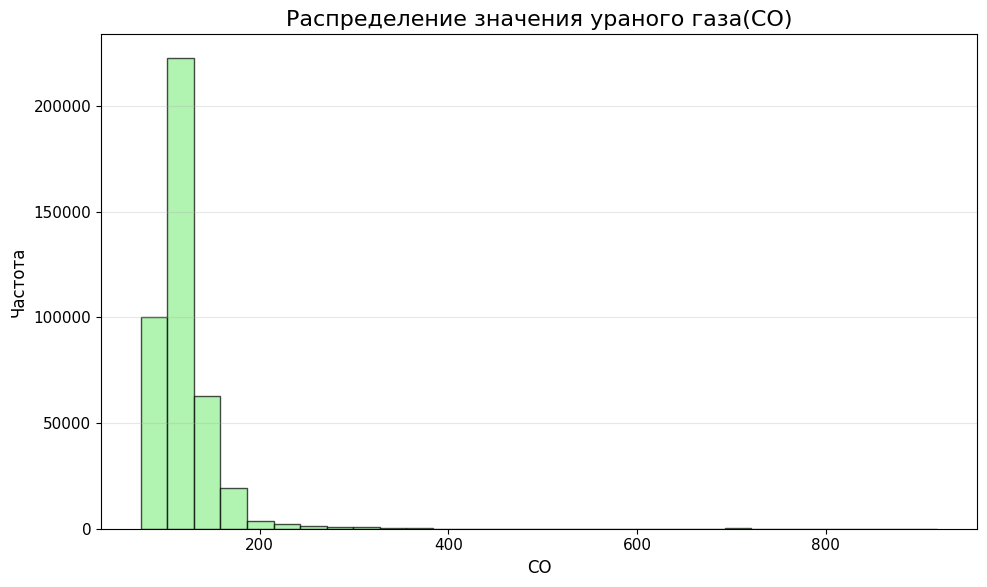

In [86]:
plt.figure(figsize=(10, 6))
plt.hist(df['temperature'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
plt.title('Распределение температуры', fontsize=16)
plt.xlabel('Температура (°C)', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df['humidity'], bins=30, edgecolor='black', alpha=0.7, color='red')
plt.title('Распределение влажности', fontsize=16)
plt.xlabel('Влажность (%)', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df['COValue'], bins=30, edgecolor='black', alpha=0.7, color='lightgreen')
plt.title('Распределение значения ураного газа (CO)', fontsize=16)
plt.xlabel('CO', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Пункт 6 : График Seaborn

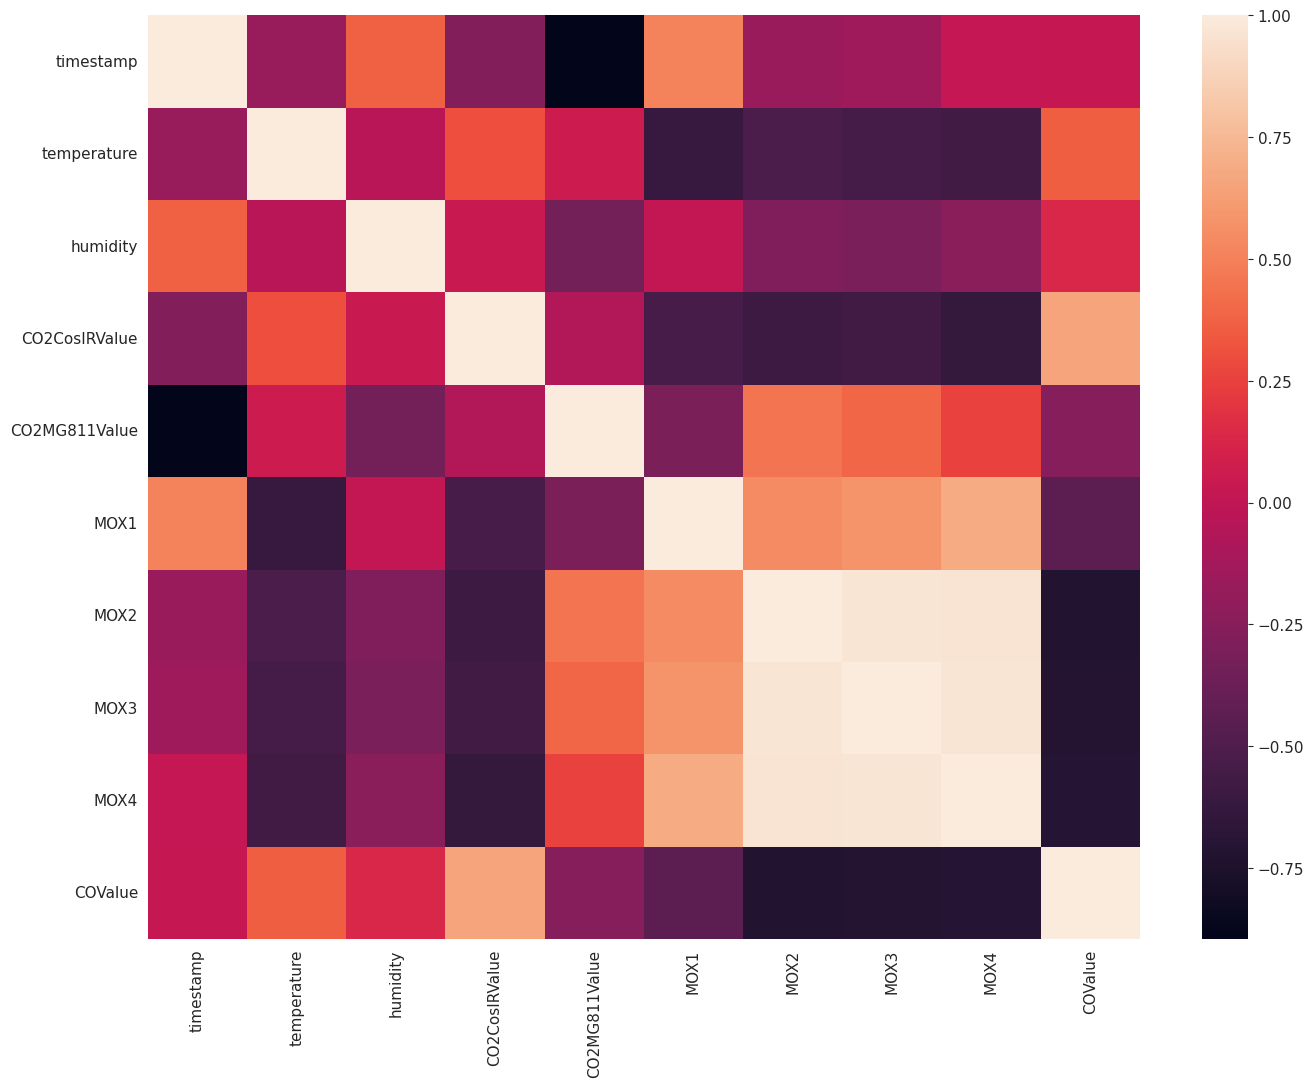

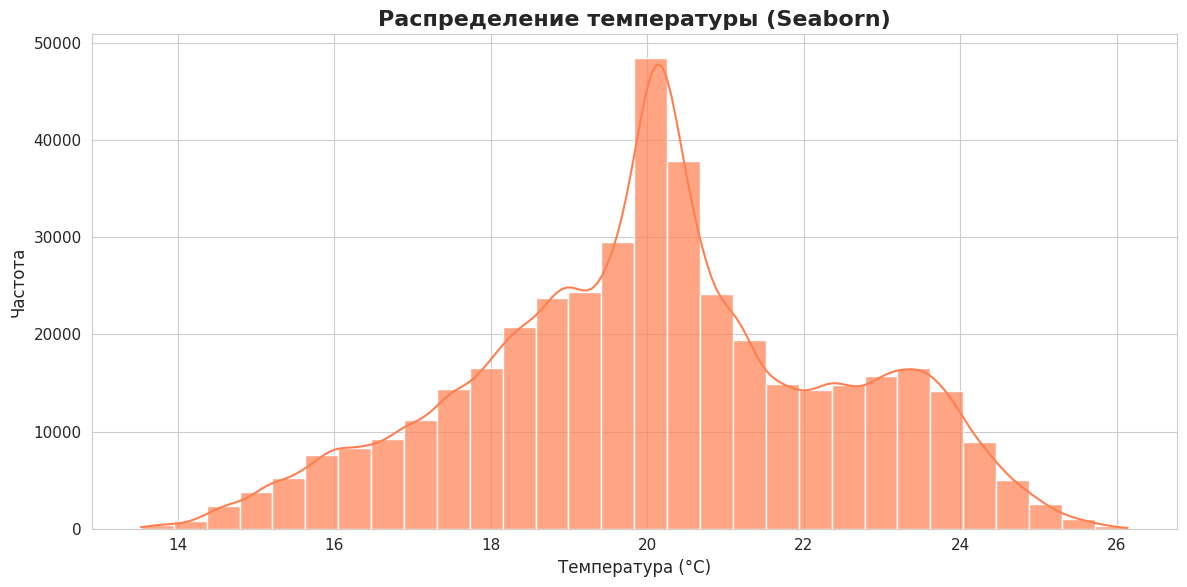

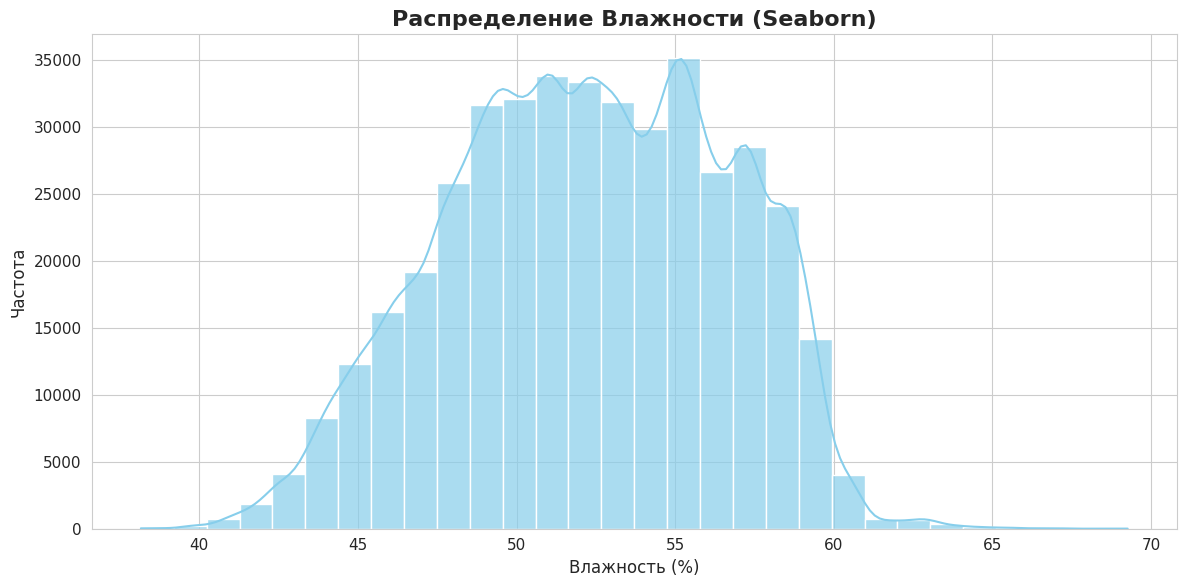

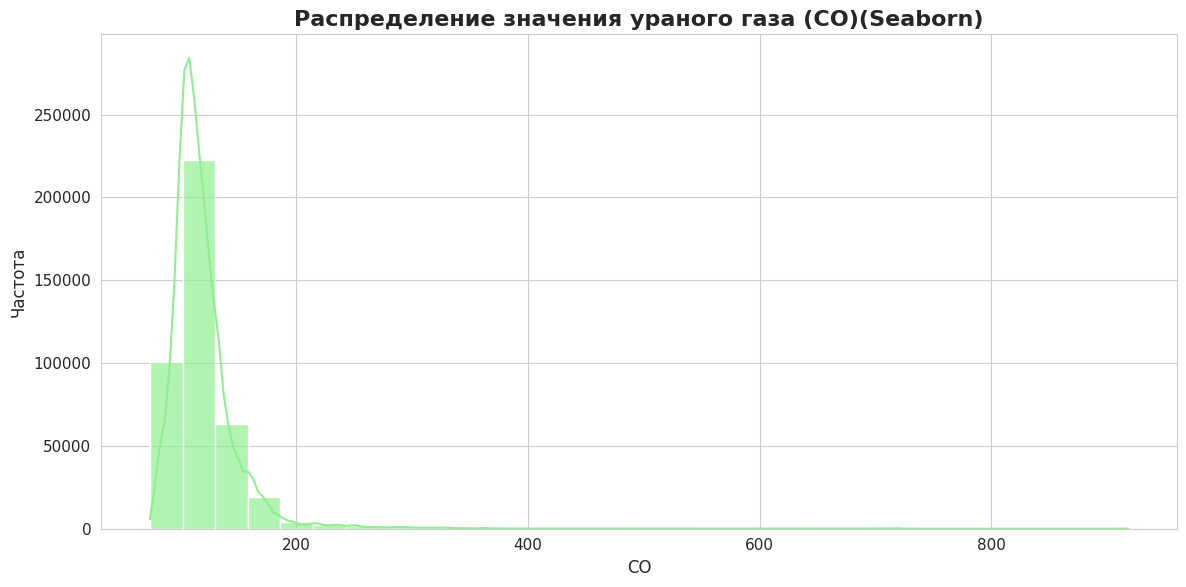

In [90]:
sns.heatmap(df.corr(numeric_only = True));

sns.set_style('whitegrid')
sns.set_palette('husl')

plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='temperature', bins=30, kde=True, color='coral', alpha=0.7)
plt.title('Распределение температуры (Seaborn)', fontsize=16, fontweight='bold')
plt.xlabel('Температура (°C)', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='humidity', bins=30, kde=True, color='skyblue', alpha=0.7)
plt.title('Распределение Влажности (Seaborn)', fontsize=16, fontweight='bold')
plt.xlabel('Влажность (%)', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='COValue', bins=30, kde=True, color='lightgreen', alpha=0.7)
plt.title('Распределение значения ураного газа (CO)(Seaborn)', fontsize=16, fontweight='bold')
plt.xlabel('CO', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.tight_layout()
plt.show()